# 07 — Krzywe uczenia

LogReg + TF-IDF char na rosnących frakcjach zbioru treningowego TwitterEmo, F1-Macro na teście. Progi strojone na pełnym val, żeby izolować efekt rozmiaru samego train.

Każda frakcja podpróbkowana 5× (ziarna 42–46); punkt = średnia, wstęga = rozstęp. Bez powtórzeń punkt zależałby od tego, które przykłady trafiły do podzbioru — przy 5% danych to wahania rzędu 0,01 F1-Macro.

In [1]:
import pickle, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import f1_score
from thesis_lib import optimal_thresholds as opt_thresholds
warnings.filterwarnings("ignore"); sns.set_theme(style="whitegrid"); plt.rcParams["savefig.dpi"]=300

EMOTIONS=["radość","smutek","zaufanie","wstręt","strach","gniew","przeczuwanie","zdziwienie"]
RANDOM_STATE=42
PROCESSED_DIR=Path("../data/processed"); CACHE_DIR=Path("../data/features")
RESULTS_DIR=Path("../data/results"); FIGURES_DIR=Path("../figures")

tw_train=pd.read_csv(PROCESSED_DIR/"twitteremo_train.csv")
tw_val=pd.read_csv(PROCESSED_DIR/"twitteremo_val.csv")
tw_test=pd.read_csv(PROCESSED_DIR/"twitteremo_test.csv")
y_train=tw_train[EMOTIONS].values; y_val=tw_val[EMOTIONS].values; y_test=tw_test[EMOTIONS].values
TW=pickle.load(open(CACHE_DIR/"TW_FEATURES.pkl","rb"))["tfidf_char"]
print("train n =",y_train.shape[0])

train n = 28684


In [2]:
#   optimal_thresholds as opt_thresholds.

In [3]:
fractions=[0.05,0.10,0.25,0.50,0.75,1.00]
N_SEEDS=5
n_full=y_train.shape[0]
rows=[]
for fr in fractions:
    n=int(round(fr*n_full))
    for seed in range(N_SEEDS):
        rng=np.random.default_rng(RANDOM_STATE+seed)
        idx=rng.choice(n_full,size=n,replace=False)
        clf=OneVsRestClassifier(LogisticRegression(max_iter=1000,C=1.0,class_weight="balanced",
                solver="liblinear",random_state=RANDOM_STATE))
        clf.fit(TW["train"][idx],y_train[idx])
        thr=opt_thresholds(y_val,clf.predict_proba(TW["val"]))
        pred=(clf.predict_proba(TW["test"])>=thr).astype(int)
        f1=f1_score(y_test,pred,average="macro",zero_division=0)
        rows.append({"fraction":fr,"n_train":n,"seed":seed,"f1_macro":f1})
    print(f"  {fr*100:5.0f}% (n={n:5d}): "
          f"F1-Macro={np.mean([r['f1_macro'] for r in rows if r['fraction']==fr]):.3f} "
          f"± {np.std([r['f1_macro'] for r in rows if r['fraction']==fr],ddof=1):.3f}")
per_seed=pd.DataFrame(rows); per_seed.to_csv(RESULTS_DIR/"learning_curve_raw.csv",index=False)
lc=(per_seed.groupby(["fraction","n_train"])["f1_macro"]
      .agg(f1_mean="mean",f1_std="std",f1_min="min",f1_max="max").reset_index().round(4))
# by dało się go zweryfikować bez ręcznego odejmowania
lc["f1_gain_prev"]=lc["f1_mean"].diff().round(4)
lc.to_csv(RESULTS_DIR/"learning_curve.csv",index=False)
display(lc)

      5% (n= 1434): F1-Macro=0.329 ± 0.011


     10% (n= 2868): F1-Macro=0.357 ± 0.013


     25% (n= 7171): F1-Macro=0.388 ± 0.009


     50% (n=14342): F1-Macro=0.416 ± 0.011


     75% (n=21513): F1-Macro=0.446 ± 0.010


    100% (n=28684): F1-Macro=0.474 ± 0.000


,fraction,n_train,f1_mean,f1_std,f1_min,f1_max,f1_gain_prev
0,0.05,1434,0.3291,0.0109,0.3186,0.3427,NaN
1,0.10,2868,0.3571,0.0125,0.3401,0.3715,0.0280
2,0.25,7171,0.3883,0.0085,0.3811,0.3993,0.0312
3,0.50,14342,0.4163,0.0109,0.4088,0.4352,0.0280
4,0.75,21513,0.4464,0.0096,0.4294,0.4530,0.0301
5,1.00,28684,0.4738,0.0000,0.4738,0.4738,0.0274


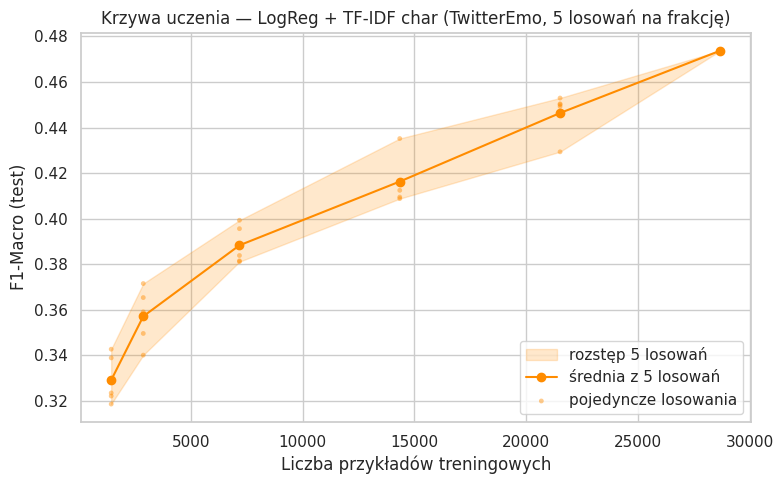

In [4]:
# Wstęga = rozstęp (min-max) z N_SEEDS losowań, czyli dokładnie obszar, w którym leżą
# narysowane kropki — samoobjaśniająca się na rysunku. Odch. std nie jest rysowane, bo
fig,ax=plt.subplots(figsize=(8,5))
ax.fill_between(lc["n_train"],lc["f1_min"],lc["f1_max"],alpha=0.2,color="darkorange",
                label=f"rozstęp {N_SEEDS} losowań")
ax.plot(lc["n_train"],lc["f1_mean"],marker="o",color="darkorange",
        label=f"średnia z {N_SEEDS} losowań")
ax.scatter(per_seed["n_train"],per_seed["f1_macro"],s=12,color="darkorange",
           alpha=0.45,zorder=3,edgecolors="none",label="pojedyncze losowania")
ax.set_xlabel("Liczba przykładów treningowych"); ax.set_ylabel("F1-Macro (test)")
ax.set_title(f"Krzywa uczenia — LogReg + TF-IDF char (TwitterEmo, {N_SEEDS} losowań na frakcję)")
ax.legend(loc="lower right",frameon=True)
plt.tight_layout(); plt.savefig(FIGURES_DIR/"learning_curve.pdf",bbox_inches="tight"); plt.show()